### EDA

- gender 성별
- age 나이
- height 키
- weight 몸무게
- eyesight(left, right) 왼쪽 시력, 오른쪽 시력
- hearing(left, right) 왼쪽 청력, 오른쪽 청력

- systolic 최고혈압(대동맥 내로 보내지는 심실 수축기의 혈압)
- relaxation 최저혈압
- fasting blood sugar 공복혈당
- Cholesterol 총 콜레스테롤
- triglyceride 중성지방
- HDL 고밀도지단백 (콜레스테롤)
- LDL 저밀도지단백 (콜레스테롤)
- hemoglobin 헤모글로빈 수치
- Urine protein 단백뇨
- serum creatinine 혈액 또는 소변에서 크레아티닌 양 측정 - *신장*관련

- AST 아스파르테이트 아미노 전달효소 *간*
- ALT 알라닌 아미노 전달효소 *간* 
    - AST, ALT의 정상 범위 ~40, 경도 40~ 200, 중등도 200~400, 중증 400~
- Gtp 감마 Gtp간 기능 검사 *알코올 관련*
    - 정상 ~50, 가벼운 증가 51~100, 중간정도의 증가 101~200, 고도의 증가 201~500, 초고도 증가 500~
    - 술 마시지 않는 사람도 높게 나올 수 있다.
    
- oral 구강검사 여부
- dental caries 충치 갯수
- tartar 치석존재여부

In [1]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

In [3]:
df = pd.read_csv('smoking.csv')
df.shape  # (55693, 27)

(55692, 27)

In [4]:
# 범주형 데이터 변환
df = df.replace({'N':0,'Y':1,'F':0,'M':1, })
gender = {'F': 0, 'M': 1}
oral = {'N': 0, 'T': 1}
tartar = {'N': 0, 'T': 1}
# df 전체 float형으로 바꾸기
df = df.astype(float)

In [5]:
df_obe = df.iloc[:, [2,3,4,5, 10,11,12,13,14,15,16]]
rename = df_obe.rename(columns={'height(cm)':'height', 'weight(kg)':'weight', 'waist(cm)':'waist'})

rename.insert(3, 'BMI', rename['weight']/(rename['height']*rename['height']), 0)

target = df.iloc[:,-1]
obesity = pd.concat([rename, target], axis = 1)
df = obesity
df

,age,height,weight,BMI,waist,systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,smoking
0,40.0,155.0,60.0,0.002497,81.3,114.0,73.0,94.0,215.0,82.0,73.0,126.0,0.0
1,40.0,160.0,60.0,0.002344,81.0,119.0,70.0,130.0,192.0,115.0,42.0,127.0,0.0
2,55.0,170.0,60.0,0.002076,80.0,138.0,86.0,89.0,242.0,182.0,55.0,151.0,1.0
3,40.0,165.0,70.0,0.002571,88.0,100.0,60.0,96.0,322.0,254.0,45.0,226.0,0.0
4,40.0,155.0,60.0,0.002497,86.0,120.0,74.0,80.0,184.0,74.0,62.0,107.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55687,40.0,170.0,65.0,0.002249,75.0,110.0,68.0,89.0,213.0,99.0,75.0,118.0,0.0
55688,45.0,160.0,50.0,0.001953,70.0,101.0,62.0,89.0,166.0,69.0,73.0,79.0,0.0
55689,55.0,160.0,50.0,0.001953,68.5,117.0,72.0,88.0,158.0,77.0,79.0,63.0,0.0
55690,60.0,165.0,60.0,0.002204,78.0,133.0,76.0,107.0,210.0,79.0,48.0,146.0,0.0


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = \
train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=42)

<br/>
<br/>
<br/>

## StandardScaler

A:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

0.6848011491157195

confusion_matrix : 
 [[5894 1133]
 [2378 1734]]


<AxesSubplot:title={'center':'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

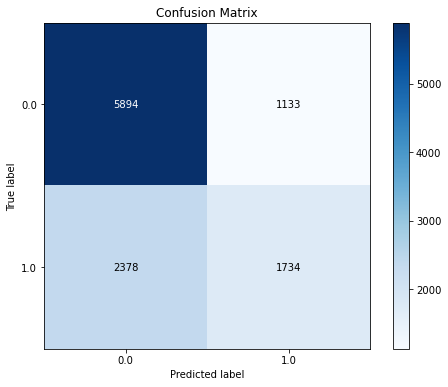

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


model = LogisticRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred) 
acc 

from sklearn.metrics import confusion_matrix 
import scikitplot as skplt 
pred = model.predict(X_test) # 실제 , 예측 
cm = confusion_matrix(y_test, pred) 
print('confusion_matrix : \n', cm) 
skplt.metrics.plot_confusion_matrix(y_test,pred,figsize=(8,6)) 
plt.show()

### 3. 훈련01

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pandas as pd

from MyModule import girdcvconv as gc


estimator = LogisticRegression()

penalty_list = ['l1', 'l2', 'elasticnet']
solver_list = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
C_list = np.arange(1,100,25)

parameter={
    
    'penalty' : penalty_list,
    'solver' : solver_list,
    'C' : C_list,
    'random_state' : [42]

    
}

model = GridSearchCV(estimator, param_grid=parameter, cv=3, verbose=1, n_jobs=-1, refit=True)
# verbose 출력 실행 모듈
model.fit(X_train,y_train)

print('best_params : ', model.best_params_)
print('best_score_ : ', model.best_score_)

gc.paramsTocsv(data_name = 'obesity', scaler = 'None', model_name = 'LogisticRegression', best_params = model.best_params_, best_score = model.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


A:\Anaconda\lib\site-packages\sklearn\model_selection\_search.py:922: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.69683299        nan 0.67898907 0.69719211
 0.67878706 0.69422934 0.67898907 0.67896662        nan        nan
        nan        nan        nan        nan        nan 0.69685543
        nan 0.67896662 0.69716966 0.68096424 0.69660853 0.67898907
 0.67896662        nan        nan        nan        nan        nan
        nan        nan 0.69660853        nan 0.67896662 0.69716966
 0.67862995 0.69649631 0.67898907 0.67896662        nan        nan
        nan        nan        nan        nan        nan 0.69586784
        nan 0.67896662 0.69716966 0.67867484 0.69656364 0.67898907
 0.67896662        nan        nan        nan        nan        nan]
  warnings.warn(


GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([ 1, 26, 51, 76]),
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'random_state': [42],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             verbose=1)

best_params :  {'C': 1, 'penalty': 'l2', 'random_state': 42, 'solver': 'newton-cg'}
best_score_ :  0.6971921082755369


<br/>
<br/>
<br/>

## MinMaxScaler

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size = 0.2, random_state = 42)

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns = list(X_train.columns)

minmax = scaler.fit_transform(X_train)
X_train = pd.DataFrame(minmax, columns = columns)
type(minmax)
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns= columns)
X_test

numpy.ndarray

,age,height,weight,BMI,waist,systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL
0,0.384615,0.454545,0.238095,0.263365,0.256410,0.236686,0.150943,0.068966,0.271795,0.071645,0.074919,0.050565
1,0.538462,0.181818,0.095238,0.173599,0.376923,0.195266,0.283019,0.103448,0.443590,0.205853,0.057003,0.078537
2,0.076923,0.636364,0.476190,0.489560,0.551282,0.230769,0.283019,0.427056,0.402564,0.343088,0.053746,0.055944
3,0.384615,0.636364,0.380952,0.363265,0.397436,0.313609,0.396226,0.193634,0.417949,0.257316,0.079805,0.079613
4,0.307692,0.545455,0.285714,0.283592,0.333333,0.307692,0.311321,0.159151,0.400000,0.130172,0.066775,0.073696
...,...,...,...,...,...,...,...,...,...,...,...,...
11134,0.461538,0.454545,0.285714,0.334652,0.320513,0.242604,0.301887,0.092838,0.417949,0.199798,0.063518,0.071544
11135,0.307692,0.727273,0.428571,0.373060,0.416667,0.195266,0.245283,0.114058,0.325641,0.071645,0.073290,0.062399
11136,0.307692,0.272727,0.380952,0.614732,0.487179,0.278107,0.358491,0.119363,0.423077,0.162462,0.078176,0.071544
11137,0.000000,0.727273,0.476190,0.432650,0.448718,0.319527,0.254717,0.129973,0.271795,0.054490,0.081433,0.050027


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pandas as pd

from MyModule import girdcvconv as gc


estimator = LogisticRegression()

penalty_list = ['l1', 'l2', 'elasticnet']
solver_list = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
C_list = np.arange(1,100,25)

parameter={
    
    'penalty' : penalty_list,
    'solver' : solver_list,
    'C' : C_list,
    'random_state' : [42]

    
}

model = GridSearchCV(estimator, param_grid=parameter, cv=3, verbose=1, n_jobs=-1, refit=True)
# verbose 출력 실행 모듈
model.fit(X_train,y_train)

print('best_params : ', model.best_params_)
print('best_score_ : ', model.best_score_)

gc.paramsTocsv(data_name = 'obesity', scaler = 'MinMaxScaler', model_name = 'LogisticRegression', best_params = model.best_params_, best_score = model.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


A:\Anaconda\lib\site-packages\sklearn\model_selection\_search.py:922: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.69690032        nan 0.69665342 0.69631675
 0.6962943  0.6958454  0.69636164 0.69631675        nan        nan
        nan        nan        nan        nan        nan 0.69737167
        nan 0.69725944 0.69710233 0.69703499 0.69714722 0.69710233
 0.69707988        nan        nan        nan        nan        nan
        nan        nan 0.69730433        nan 0.69732678 0.69721455
 0.69725944 0.69719211 0.69721455 0.69719211        nan        nan
        nan        nan        nan        nan        nan 0.69725944
        nan 0.69734922 0.69712477 0.69716966 0.69716966 0.69712477
 0.69714722        nan        nan        nan        nan        nan]
  warnings.warn(
A:\Anaconda\lib\site-packages\sklearn\svm\_base.py:985: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn("Liblinear failed to conv

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([ 1, 26, 51, 76]),
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'random_state': [42],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             verbose=1)

best_params :  {'C': 26, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear'}
best_score_ :  0.6973716696967657


<br><br><br>
## StandardScaler

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size = 0.2, random_state = 42)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = list(X_train.columns)

std = scaler.fit_transform(X_train)
X_train = pd.DataFrame(std, columns = columns)
type(std)
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns= columns)
X_test

numpy.ndarray

,age,height,weight,BMI,waist,systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL
0,0.066832,-0.506775,-0.849383,-0.772759,-1.192457,-0.764449,-2.059436,-1.315515,-0.986579,-0.665546,-0.492275,-0.488192
1,0.894628,-2.138394,-2.020689,-1.481145,-0.178884,-1.274481,-0.617902,-0.690879,0.862475,1.190581,-1.235741,0.795221
2,-1.588759,0.580971,1.102794,1.012255,1.287562,-0.837311,-0.617902,5.171091,0.420910,3.088576,-1.370916,-0.241382
3,0.066832,0.580971,0.321923,0.015606,-0.006361,0.182752,0.617699,0.942785,0.586497,1.902329,-0.289511,0.844583
4,-0.347065,0.037098,-0.458948,-0.613134,-0.545496,0.109890,-0.309002,0.318149,0.393312,0.143893,-0.830214,0.573092
...,...,...,...,...,...,...,...,...,...,...,...,...
11134,0.480730,-0.506775,-0.458948,-0.210197,-0.653323,-0.691588,-0.411969,-0.883075,0.586497,1.106846,-0.965389,0.474368
11135,-0.347065,1.124844,0.712359,0.092897,0.155379,-1.274481,-1.029769,-0.498683,-0.407025,-0.665546,-0.559862,0.054790
11136,-0.347065,-1.594521,0.321923,2.000045,0.748428,-0.254418,0.205832,-0.402585,0.641692,0.590480,-0.357099,0.474368
11137,-2.002656,1.124844,1.102794,0.563153,0.424947,0.255613,-0.926802,-0.210389,-0.986579,-0.902795,-0.221923,-0.512873


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pandas as pd

from MyModule import girdcvconv as gc


estimator = LogisticRegression()

penalty_list = ['l1', 'l2', 'elasticnet']
solver_list = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
C_list = np.arange(1,100,25)

parameter={
    
    'penalty' : penalty_list,
    'solver' : solver_list,
    'C' : C_list,
    'random_state' : [42]

    
}

model = GridSearchCV(estimator, param_grid=parameter, cv=3, verbose=1, n_jobs=-1, refit=True)
# verbose 출력 실행 모듈
model.fit(X_train,y_train)

print('best_params : ', model.best_params_)
print('best_score_ : ', model.best_score_)

gc.paramsTocsv(data_name = 'obesity', scaler = 'StandardScaler', model_name = 'LogisticRegression', best_params = model.best_params_, best_score = model.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


A:\Anaconda\lib\site-packages\sklearn\model_selection\_search.py:922: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.69716966        nan 0.6969901  0.697237
 0.69721455 0.697237   0.69716966 0.69705744        nan        nan
        nan        nan        nan        nan        nan 0.69732678
        nan 0.69707988 0.69734922 0.69737167 0.69734922 0.69716966
 0.69705744        nan        nan        nan        nan        nan
        nan        nan 0.69732678        nan 0.69707988 0.69739411
 0.69739411 0.69734922 0.69716966 0.69707988        nan        nan
        nan        nan        nan        nan        nan 0.69732678
        nan 0.69707988 0.69739411 0.69739411 0.69739411 0.69716966
 0.69707988        nan        nan        nan        nan        nan]
  warnings.warn(


GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([ 1, 26, 51, 76]),
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'random_state': [42],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             verbose=1)

best_params :  {'C': 51, 'penalty': 'l2', 'random_state': 42, 'solver': 'newton-cg'}
best_score_ :  0.6973941148744193


<br/>
<br/>
<br/>

## RobustScaler

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size = 0.33, random_state = 42)

In [16]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
columns = list(X_train.columns)

rob = scaler.fit_transform(X_train)
X_train = pd.DataFrame(rob, columns = columns)
type(std)
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns= columns)
X_test

numpy.ndarray

,age,height,weight,BMI,waist,systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL
0,0.333333,-0.5,-0.50,-0.529216,-0.901639,-0.500000,-1.666667,-1.600000,-0.723404,-0.337209,-0.263158,-0.409091
1,1.000000,-2.0,-1.25,-1.073632,-0.131148,-0.888889,-0.500000,-0.733333,0.702128,1.209302,-0.842105,0.772727
2,-1.000000,0.5,0.75,0.842620,0.983607,-0.555556,-0.500000,7.400000,0.361702,2.790698,-0.947368,-0.181818
3,0.333333,0.5,0.25,0.076666,0.000000,0.222222,0.500000,1.533333,0.489362,1.802326,-0.105263,0.818182
4,0.000000,0.0,-0.25,-0.406540,-0.409836,0.166667,-0.250000,0.666667,0.340426,0.337209,-0.526316,0.568182
...,...,...,...,...,...,...,...,...,...,...,...,...
18374,0.000000,-0.5,0.25,0.767820,0.491803,-0.055556,1.083333,0.600000,0.893617,1.372093,-0.736842,0.863636
18375,-0.666667,1.5,0.25,-0.502528,0.327869,-0.166667,-0.833333,-0.133333,-0.234043,-0.709302,1.315789,-0.431818
18376,1.333333,0.0,0.00,0.000000,0.311475,0.277778,0.000000,-0.400000,-1.510638,0.430233,-0.947368,-1.250000
18377,0.000000,-1.0,-0.75,-0.678130,-1.475410,0.166667,0.000000,-0.066667,-0.276596,-0.244186,0.105263,-0.136364


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pandas as pd

from MyModule import girdcvconv as gc


estimator = LogisticRegression()

penalty_list = ['l1', 'l2', 'elasticnet']
solver_list = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
C_list = np.arange(1,100,25)

parameter={
    
    'penalty' : penalty_list,
    'solver' : solver_list,
    'C' : C_list,
    'random_state' : [42]

    
}

model = GridSearchCV(estimator, param_grid=parameter, cv=3, verbose=1, n_jobs=-1, refit=True)
# verbose 출력 실행 모듈
model.fit(X_train,y_train)

print('best_params : ', model.best_params_)
print('best_score_ : ', model.best_score_)

gc.paramsTocsv(data_name = 'obesity', scaler = 'RobustScaler', model_name = 'LogisticRegression', best_params = model.best_params_, best_score = model.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


A:\Anaconda\lib\site-packages\sklearn\model_selection\_search.py:922: UserWarning: One or more of the test scores are non-finite: [       nan        nan 0.69611131        nan 0.6966205  0.69589689
 0.69589689 0.69587009 0.69608449 0.6967277         nan        nan
        nan        nan        nan        nan        nan 0.6962453
        nan 0.69672771 0.6962453  0.6962453  0.6962453  0.6960845
 0.69672771        nan        nan        nan        nan        nan
        nan        nan 0.6962453         nan 0.69675451 0.6962453
 0.69621849 0.6962453  0.6960845  0.69675451        nan        nan
        nan        nan        nan        nan        nan 0.6962453
        nan 0.69675451 0.6962185  0.6962185  0.6962185  0.6960845
 0.69675451        nan        nan        nan        nan        nan]
  warnings.warn(
A:\Anaconda\lib\site-packages\sklearn\linear_model\_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reach

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([ 1, 26, 51, 76]),
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'random_state': [42],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             verbose=1)

best_params :  {'C': 51, 'penalty': 'l1', 'random_state': 42, 'solver': 'saga'}
best_score_ :  0.6967545113656799


In [7]:
## 예시
# from MyModule import girdcvconv as gc
# best_params =  {'criterion': 'gini', 'max_depth': 19, 'min_impurity_decrease': 0.0, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': 42, 'splitter': 'best'}
# best_score_ =  0.7113550153749467
# gc.paramsTocsv(data_name='obesity', scaler='StandardScaler', model_name='DecisionTreeClassifier', best_params=best_params, best_score=best_score_)

In [8]:
# 생성된 dataframe 확인
import pandas as pd
df = pd.read_csv('./modeldata/obesity.csv')
df

,date,model_name,scaler,best_score,criterion,max_depth,min_impurity_decrease,min_samples_split,min_weight_fraction_leaf,random_state,splitter
0,2022-11-21 13:42:55,DecisionTreeClassifier,StandardScaler,0.711355,gini,19,0.0,2,0.0,42,best
1,2022-11-21 13:43:08,DecisionTreeClassifier,StandardScaler,0.711355,gini,19,0.0,2,0.0,42,best


In [10]:
# 특정 데이터프레임 선택
import pandas as pd
from MyModule import selectparameter as sp

bestparams = sp.selectparam('obesity',0)
print(bestparams)

{'criterion': ['gini'], 'max_depth': [19], 'min_impurity_decrease': [0.0], 'min_samples_split': [2], 'min_weight_fraction_leaf': [0.0], 'random_state': [42], 'splitter': ['best']}


Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini'], 'max_depth': [19],
                         'min_impurity_decrease': [0.0],
                         'min_samples_split': [2],
                         'min_weight_fraction_leaf': [0.0],
                         'random_state': [42], 'splitter': ['best']},
             verbose=1)

confusion_matrix : 
 [[5510 1517]
 [1423 2689]]


<AxesSubplot: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

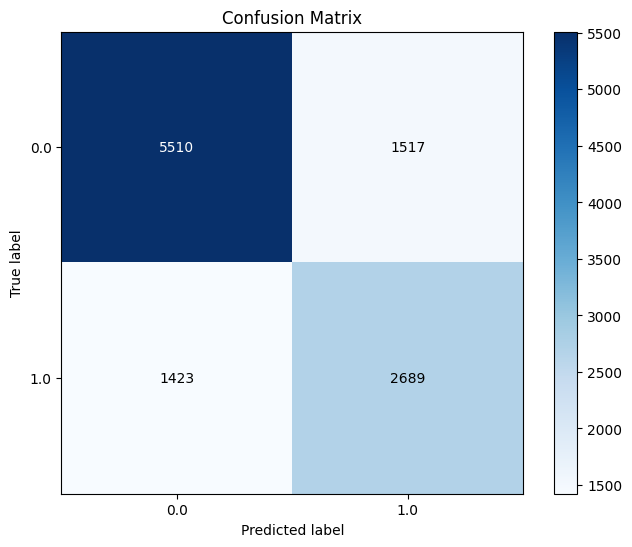

리포트:
               precision    recall  f1-score   support

         0.0       0.79      0.78      0.79      7027
         1.0       0.64      0.65      0.65      4112

    accuracy                           0.74     11139
   macro avg       0.72      0.72      0.72     11139
weighted avg       0.74      0.74      0.74     11139



In [12]:
#DecisionTreeClassifier 최적의 파라미터를 바로 삽입 : 30%
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

estimator = DecisionTreeClassifier()
model = GridSearchCV(estimator, param_grid=bestparams, cv=3, verbose=1, n_jobs=-1, refit=True)
# verbose 출력 실행 모듈
model.fit(X_train,y_train)

from sklearn.metrics import confusion_matrix
import scikitplot as skplt

pred = model.predict(X_test)
# 실제 , 예측
cm = confusion_matrix(y_test, pred)
print('confusion_matrix : \n', cm)

skplt.metrics.plot_confusion_matrix(y_test,pred,figsize=(8,6))
plt.show()

cl_report = metrics.classification_report(y_test,pred)
print('리포트:\n',cl_report)

#### RandomForestClassifier



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()
model.fit(X_train,y_train)

pred = model.predict(X_train)
accuracy_score(y_train,pred)
print("*"*10)
pred_test = model.predict(X_test)
accuracy_score(y_test,pred_test)

from sklearn.metrics import confusion_matrix
import scikitplot as skplt

pred = model.predict(X_test)
# 실제 , 예측
cm = confusion_matrix(y_test, pred)
print('confusion_matrix : \n', cm)

skplt.metrics.plot_confusion_matrix(y_test,pred,figsize=(8,6))
plt.show()

cl_report = metrics.classification_report(y_test,pred)
print('리포트:\n',cl_report)

RandomForestClassifier()

1.0

**********


0.8301463327049107

ValueError: Found input variables with inconsistent numbers of samples: [11139, 44553]

### XGBoost

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=10, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_bin=256, max_cat_threshold=64, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0, ...)

0.7782565759942545

confusion_matrix : 
 [[5725 1302]
 [1168 2944]]


<AxesSubplot:title={'center':'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

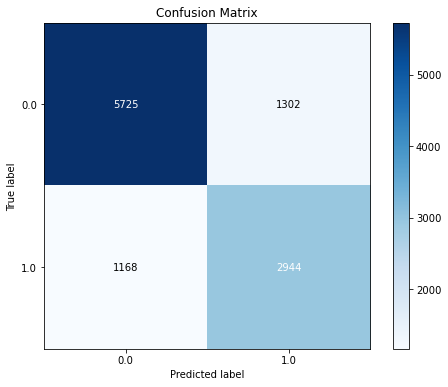

리포트:
               precision    recall  f1-score   support

         0.0       0.83      0.81      0.82      7027
         1.0       0.69      0.72      0.70      4112

    accuracy                           0.78     11139
   macro avg       0.76      0.77      0.76     11139
weighted avg       0.78      0.78      0.78     11139



In [12]:
#XGBoost1
import xgboost as xgb
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = xgb.XGBClassifier(early_stopping_rounds=10)
eval_set = [(X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)#, verbose=True

pred = model.predict(X_test)
acc = accuracy_score(y_test,pred)
acc

from sklearn.metrics import confusion_matrix
import scikitplot as skplt

pred = model.predict(X_test)
# 실제 , 예측
cm = confusion_matrix(y_test, pred)
print('confusion_matrix : \n', cm)

skplt.metrics.plot_confusion_matrix(y_test,pred,figsize=(8,6))
plt.show()

cl_report = metrics.classification_report(y_test,pred)
print('리포트:\n',cl_report)

99
0.4427296433494823


0.44272964488104294

array([0.00426044, 0.8394392 , 0.01212047, 0.00586408, 0.00541682,
       0.0057042 , 0.00469223, 0.00379801, 0.00536723, 0.00401257,
       0.00521885, 0.00487424, 0.00482933, 0.00532099, 0.00725594,
       0.00564713, 0.00542283, 0.0054879 , 0.004886  , 0.00651039,
       0.00606318, 0.00651765, 0.01426078, 0.        , 0.0138058 ,
       0.01322366], dtype=float32)

<BarContainer object of 26 artists>

리포트:
               precision    recall  f1-score   support

         0.0       0.83      0.81      0.82      7027
         1.0       0.69      0.72      0.70      4112

    accuracy                           0.78     11139
   macro avg       0.76      0.77      0.76     11139
weighted avg       0.78      0.78      0.78     11139



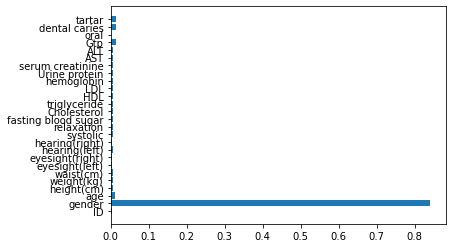

In [14]:
#XGBoost2
# best_iteration
print(model.best_iteration)
print(model.best_score)

from sklearn import metrics
y_pred = model.predict_proba(X_test)
metrics.log_loss(y_test, y_pred)

# feature_importances_
import matplotlib.pyplot as plt 
model.feature_importances_
plt.barh(df.iloc[:,:-1].columns, model.feature_importances_)

cl_report = metrics.classification_report(y_test,pred)
print('리포트:\n',cl_report)

### LGBMClassifier

[1]	valid_0's binary_logloss: 0.629699
Training until validation scores don't improve for 10 rounds
[2]	valid_0's binary_logloss: 0.606
[3]	valid_0's binary_logloss: 0.585945
[4]	valid_0's binary_logloss: 0.569196
[5]	valid_0's binary_logloss: 0.555091
[6]	valid_0's binary_logloss: 0.542841
[7]	valid_0's binary_logloss: 0.532537
[8]	valid_0's binary_logloss: 0.523629
[9]	valid_0's binary_logloss: 0.515708
[10]	valid_0's binary_logloss: 0.509227
[11]	valid_0's binary_logloss: 0.503696
[12]	valid_0's binary_logloss: 0.498912
[13]	valid_0's binary_logloss: 0.494652
[14]	valid_0's binary_logloss: 0.490412
[15]	valid_0's binary_logloss: 0.487037
[16]	valid_0's binary_logloss: 0.484325
[17]	valid_0's binary_logloss: 0.481851
[18]	valid_0's binary_logloss: 0.479704
[19]	valid_0's binary_logloss: 0.47807
[20]	valid_0's binary_logloss: 0.476475
[21]	valid_0's binary_logloss: 0.474732
[22]	valid_0's binary_logloss: 0.473286
[23]	valid_0's binary_logloss: 0.472173
[24]	valid_0's binary_logloss: 0

LGBMClassifier(boosting_type='goss', max_depth=5, random_state=0)

0.762905108178472

confusion_matrix : 
 [[5573 1454]
 [1187 2925]]


<AxesSubplot:title={'center':'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

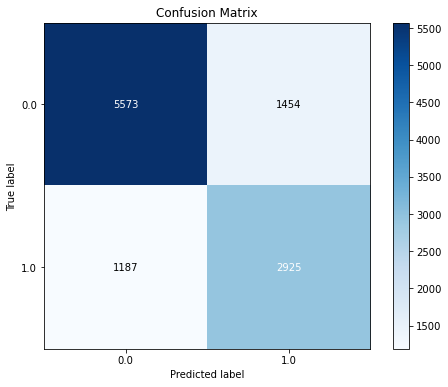

리포트:
               precision    recall  f1-score   support

         0.0       0.82      0.79      0.81      7027
         1.0       0.67      0.71      0.69      4112

    accuracy                           0.76     11139
   macro avg       0.75      0.75      0.75     11139
weighted avg       0.77      0.76      0.76     11139



In [18]:
import lightgbm as lgb # 분류 회귀 다 됨
model = lgb.LGBMClassifier(boosting_type='goss',max_depth=5, random_state=0)
eval_set = [(X_test, y_test)]
callbacks = []  # 리스트 객체 사용자함수를 담을 곳
callbacks.append(lgb.early_stopping(stopping_rounds=10)) # 부스팅 반복 횟수 제어
callbacks.append(lgb.log_evaluation())
model.fit(X_train, y_train, eval_set=eval_set, callbacks=callbacks)

pred = model.predict(X_test)
acc = accuracy_score(y_test,pred)
acc

from sklearn.metrics import confusion_matrix
import scikitplot as skplt

pred = model.predict(X_test)
# 실제 , 예측
cm = confusion_matrix(y_test, pred)
print('confusion_matrix : \n', cm)

skplt.metrics.plot_confusion_matrix(y_test,pred,figsize=(8,6))
plt.show()

cl_report = metrics.classification_report(y_test,pred)
print('리포트:\n',cl_report)

In [171]:
print(model.best_iteration_)
print(model.best_score_)

97
defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict([('binary_logloss', 0.4557287150523791)])})


In [172]:
from sklearn import metrics
y_pred = model.predict_proba(X_test)
metrics.log_loss(y_test, y_pred)

0.4557287150523791

<AxesSubplot:title={'center':'Metric during training'}, xlabel='Iterations', ylabel='binary_logloss'>

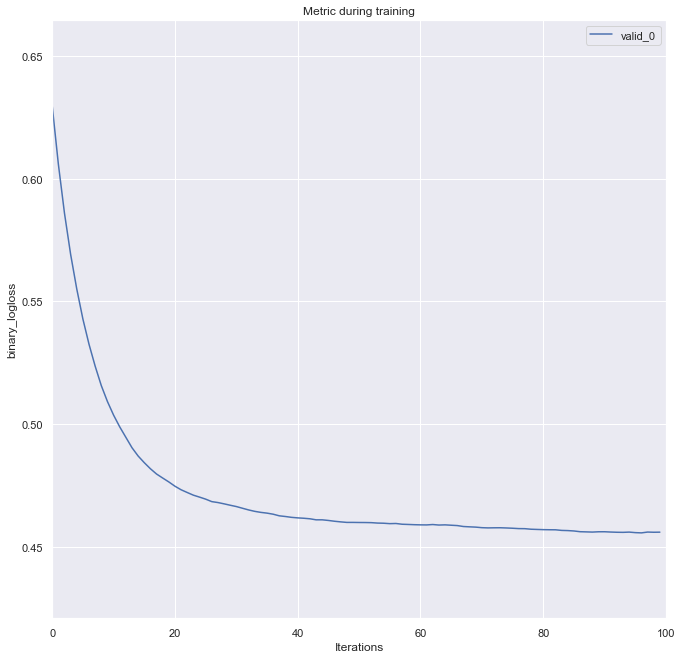

In [173]:
lgb.plot_metric(model)

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

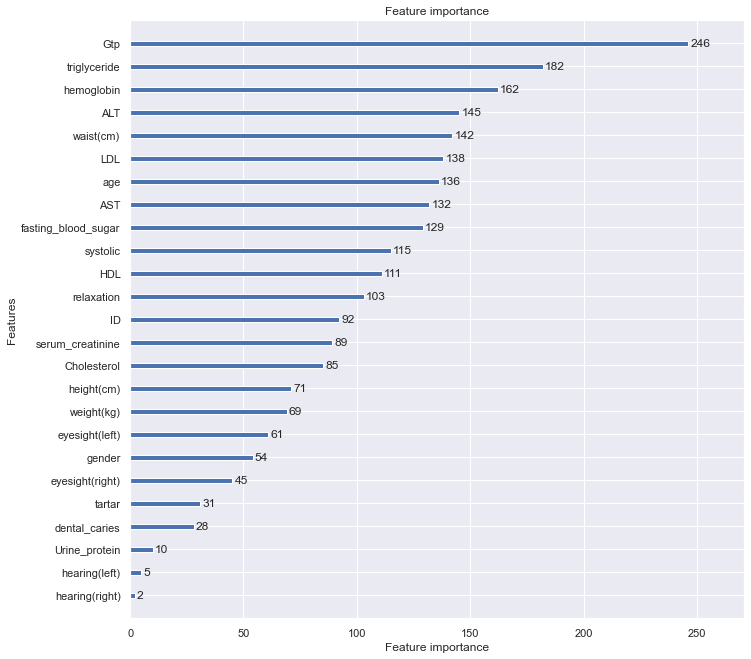

In [174]:
lgb.plot_importance(model)

### Logistic Regression

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression(max_iter = 10000)

model2.fit(X_train,y_train)

import joblib
joblib.dump(model2, 'MINIproject')

model2.score(X_test,y_test)
pred_2 = model2.predict(X_test)
acc2 = accuracy_score(y_test,pred_2)
acc2

# 실제 , 예측
cm_2 = confusion_matrix(y_test, pred)
print('confusion_matrix : \n', cm_2)

skplt.metrics.plot_confusion_matrix(y_test,pred_2,figsize=(8,6))
plt.show()

cl_report = metrics.classification_report(y_test,pred)
print('리포트:\n',cl_report)

### Support Vector Machine

In [ ]:
### 모델 - svm ###
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
model = svm.SVC()

kernel_list = ['rbf']
C_list = [1]
gamma_list = [0.3]

param = {'kernel' : kernel_list , 'C' : C_list, 'gamma':gamma_list}

model = GridSearchCV(model, param, cv=5,n_jobs=-1)
model.fit(X_train, y_train)

# 결과 확인
print('best_params : ', model.best_params_)
print('best_score_ : ', model.best_score_)


# pred = model.predict(X_test)
# acc = accuracy_score(y_test, pred) 
# acc 

# from sklearn.metrics import confusion_matrix 
# import scikitplot as skplt 

# pred = model.predict(X_test) # 실제 , 예측 
# cm = confusion_matrix(y_test, pred) 
# print('confusion_matrix : \n', cm) 
# skplt.metrics.plot_confusion_matrix(y_test,pred,figsize=(8,6)) 
# plt.show()


In [6]:
# df01
# df02
# df03

# df04 = pd.concat([df01,df02,df03],axis=1)

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = \
# train_test_split(df04.iloc[:,:-1], df04.iloc[:,-1], test_size=0.2, random_state=42)


# # 비만 
# X_train_sersea = X_train.iloc[13:,:-1]
# X_test = X_test
# y_train = y_train.iloc[13:,:-1]
# y_test = y_test